## Question 4.

--------

### V-plot (2 marks)

You can imagine when a protein binds to DNA, then that region will be protected
by nucleases (a type of enzyme that cleaves DNA). If you are to plot the
protected fragments at protein binding sites, it will take a V-form. Your goal
is to show this V-formation using the input data. 

[data](https://figshare.com/ndownloader/files/49307590?private_link=972ecdfe69d6ce038ca0)


From every line of this file, you have to derive three values:

- X: Difference between two centers. C1 = center using Column3 and Column4, C2 = center using Column9 and Column10. X-coordinate will be C2 - C1 

- Y: Column10 - Column9 

- Z: Counter of Y at X. By default Z for Y at X is Zero. 

And example is:

-500 65 10

X: -500, Y: 65, and Z: 10, telling that 500 bases relative to protein bound to DNA has 10 fragments of 65 base pair in size.
You have to plot a heatmap of this. 

--------

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
def load_data(input_file_path):
    data = pd.read_csv(input_file_path, sep='\t', header=None)
    return data

input_file = 'mapped.bed.gz'  
df = load_data(input_file)
print(f"Total Data: {df.shape[0]} rows and {df.shape[1]} columns \n")

display(df.head())

Total Data: 4336134 rows and 13 columns 



,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838,91006,IH02_00.pairs@15152,168,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846,90998,IH02_04.pairs@4163,152,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851,91000,IH02_04.pairs@4164,149,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850,91014,IH02_00.pairs@15153,164,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900,90965,IH02_00.pairs@15164,65,+


In [25]:
def compute_xyz(dataframe):
    dataframe['Center1'] = (dataframe[2] + dataframe[3]) / 2
    dataframe['Center2'] = (dataframe[8] + dataframe[9]) / 2

    # Calculating X: difference between centers
    dataframe['X'] = (dataframe['Center2'] - dataframe['Center1']).round()
    dataframe['X'] = dataframe['X'].fillna(0).astype(int)

    # Calculating Y: fragment size
    dataframe['Y'] = dataframe[9] - dataframe[8]

    grouped_data = dataframe.groupby(['X', 'Y']).size().reset_index(name='Z')
    return grouped_data

xyz_result = compute_xyz(df)

print("Some X, Y, Z values:")
display(xyz_result.head())

Some X, Y, Z values:


,X,Y,Z
0,-509,44,7
1,-509,46,10
2,-509,48,7
3,-509,50,21
4,-509,52,17


Plot saved to Vplot.png


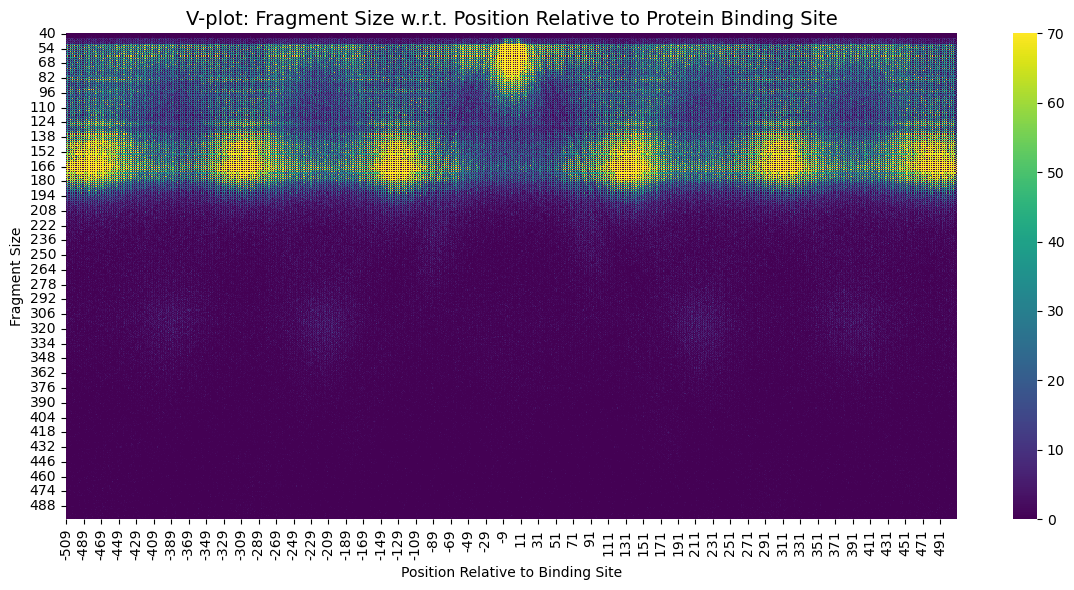

In [26]:
def create_vplot(xyz_data, output_file=None):

    pivot_data = xyz_data.pivot_table(values='Z', index='Y', columns='X', fill_value=0)

    plt.figure(figsize=(12, 6))

    sns.heatmap(pivot_data, cmap='viridis', robust=True)


    plt.xlabel('Position Relative to Binding Site')
    plt.ylabel('Fragment Size')
    plt.title('V-plot: Fragment Size w.r.t. Position Relative to Protein Binding Site', fontsize=14)


    cbar = plt.gca().collections[0].colorbar

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")

    return plt


# Main Workspace
vplot = create_vplot(xyz_result, output_file='Vplot.png')
plt.show()